In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch
from torch import nn
import numpy as np
import pandas as pd
import datetime
import sys
from pathlib import Path
from torch.utils.data import DataLoader
from torch.optim import Adam

# InfluPaint modular imports
from influpaint.utils import SeasonAxis, plotting as idplots
from influpaint.batch.scenarios import get_training_scenario, create_scenario_objects
from influpaint.batch.config import copaint_config_library, create_folders, get_git_revision_short_hash
from influpaint.utils import ground_truth
from influpaint.datasets import loaders as training_datasets
from influpaint.batch.config import transform_library
# CoPaint imports
sys.path.append('CoPaint4influpaint')
from guided_diffusion import O_DDIMSampler

# Configure plotting
sns.set_style("whitegrid")
%matplotlib inline

season_setup = SeasonAxis.for_flusight(remove_us=True, remove_territories=True)
image_size = 64
channels = 1
batch_size=512
epochs=50
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Spatial Setup with 51 locations, with a season start_date of Aug 01
Using device: cuda


In [ ]:
scn_id = 868  # Choose your training scenario
experiment_name = "demo_jan2026"  # MLflow experiment name
scenario_spec = get_training_scenario(scn_id)
ddpm, dataset, transform, enrich, scaling_per_channel, data_mean, data_sd = create_scenario_objects(
            scenario_spec, season_setup, image_size, channels, batch_size, epochs, device)

created dataset with max [24573.12361303], full dataset has shape (3223, 1, 64, 64)
test passed: back and forth transformation are ok ✅


created dataset with max [24573.12361303], full dataset has shape (3223, 1, 64, 64)
test passed: back and forth transformation are ok ✅


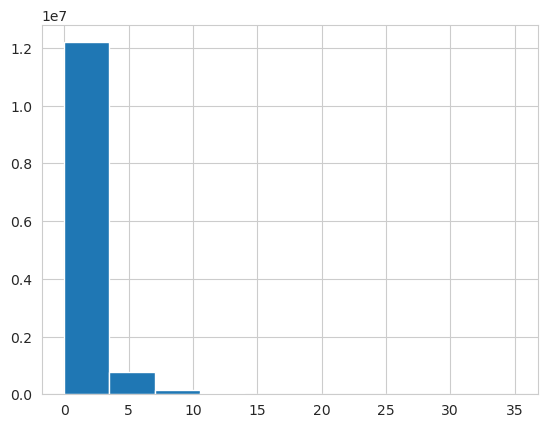

In [31]:
dataset = training_datasets.FluDataset.from_xarray("training_datasets/TS_30S70M_2025-07-17.nc",channels=channels,)
scaling_per_channel = np.array(dataset.max_per_feature) # one number per channel 
scaling_per_channel = 80

transforms_spec, transform_enrich = transform_library(
    scaling_per_channel,
    data_mean=dataset.flu_dyn.mean(),
    data_std=dataset.flu_dyn.std(),
)
transform = transforms_spec[scenario_spec.transform_name]
enrich = transform_enrich[scenario_spec.enrich_name]
dataset.add_transform(
    transform=transform["reg"],
    transform_inv=transform["inv"],
    transform_enrich=enrich,
    bypass_test=False,
)

all_samples = np.array([sample.numpy() for sample in dataset]) #dataset is an iterable that yields tensors tranformed
plt.hist(all_samples.flatten());

50

In [35]:
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
losses = ddpm.train(dataloader, mlflow_logging=True)

/!\ training on cuda
NVIDIA H100 NVL -- Allocated: 0.0GB, Cached: 0.1GB -- 92.0/93.1 (free/total)


/nas/longleaf/home/chadi/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch: 0    -- Step: 0    -- Loss: 1.137181
Epoch 0 completed - Avg Loss: 1.687238
Epoch: 1    -- Step: 0    -- Loss: 1.838632
Epoch 1 completed - Avg Loss: 1.243806
Epoch: 2    -- Step: 0    -- Loss: 1.074437
Epoch 2 completed - Avg Loss: 1.049016
Epoch: 3    -- Step: 0    -- Loss: 1.113329
Epoch 3 completed - Avg Loss: 1.035596
Epoch: 4    -- Step: 0    -- Loss: 1.002009
Epoch 4 completed - Avg Loss: 1.001870
Epoch: 5    -- Step: 0    -- Loss: 0.996559
Epoch 5 completed - Avg Loss: 0.993288
Epoch: 6    -- Step: 0    -- Loss: 0.987099
Epoch 6 completed - Avg Loss: 0.986741
Epoch: 7    -- Step: 0    -- Loss: 0.983238
Epoch 7 completed - Avg Loss: 0.978671
Epoch: 8    -- Step: 0    -- Loss: 0.973271
Epoch 8 completed - Avg Loss: 0.970560
Epoch: 9    -- Step: 0    -- Loss: 0.960710
Epoch 9 completed - Avg Loss: 0.954519
Epoch: 10   -- Step: 0    -- Loss: 0.938149
Epoch 10 completed - Avg Loss: 0.919003
Epoch: 11   -- Step: 0    -- Loss: 0.883664
Epoch 11 completed - Avg Loss: 0.816744
Ep

In [36]:
checkpoint_path = f"demo.pth"
ddpm.write_train_checkpoint(save_path=checkpoint_path)

'demo.pth'

you need to give something to a pytorch.Dataloader, it wants iterable

In [37]:
ddpm.model.eval()
ddpm.model.to(device)

ft_samples = ddpm.sample() # list of size n_diff_step.


sampling loop time step: 100%|██████████| 500/500 [00:44<00:00, 11.30it/s]


In [50]:
ft_samples[0].shape

(512, 1, 64, 64)

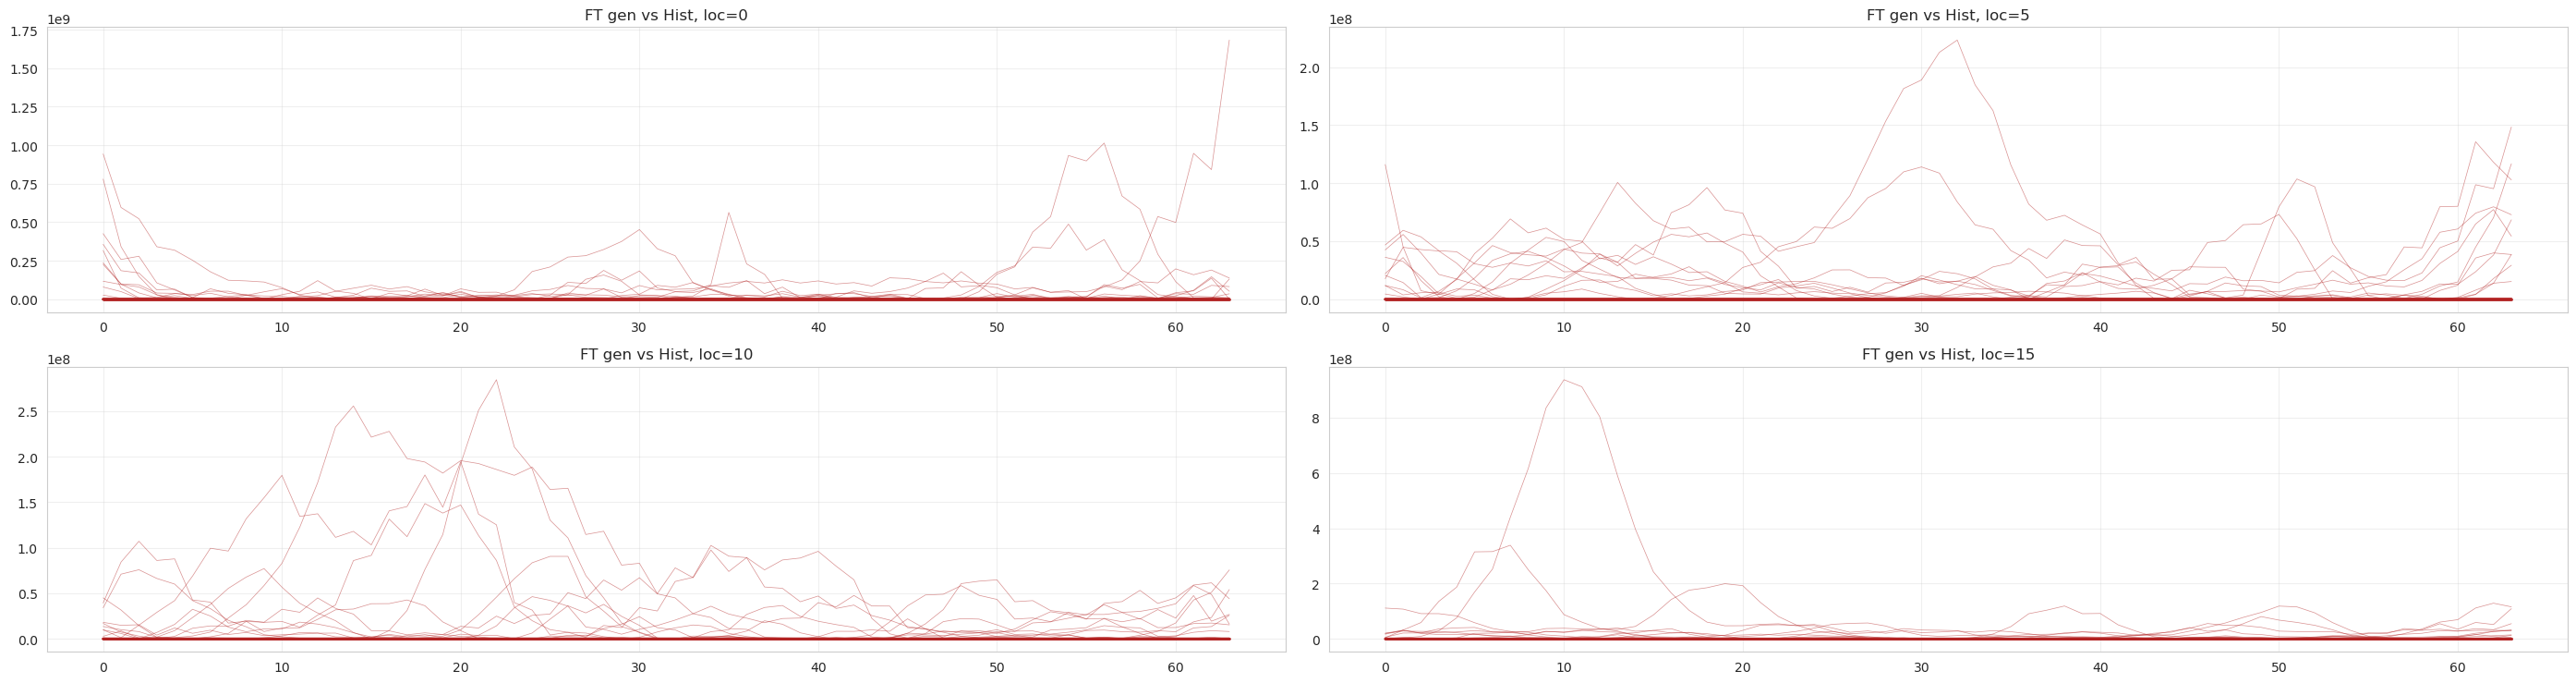

In [ ]:
n_show = min(batch_size, 10)

fig, axes = plt.subplots(2, 2, figsize=(2.8 * n_show, 7.5), dpi=100)
for k, loc in enumerate([ 0, 5, 10, 15]):
    ax = axes.flat[k]
    for i in np.arange(3):
        hist_img = dataset.get_sample_raw(i)
        idplots.show_tensor_image(hist_img, ax=ax, place=loc, multi=False) # thicker curve are historical data
    for i in np.arange(n_show):
        gen_img = dataset.apply_transform_inv(ft_samples[-1][i]) # -1 because i want the last step of the diffusion
        idplots.show_tensor_image(gen_img, ax=ax, place=loc, multi=True) # thinner curve are generation
        
    ax.set_title(f"FT gen vs Hist, loc={loc}")
    ax.grid(visible=True, alpha=0.3)
plt.tight_layout()
plt.show()

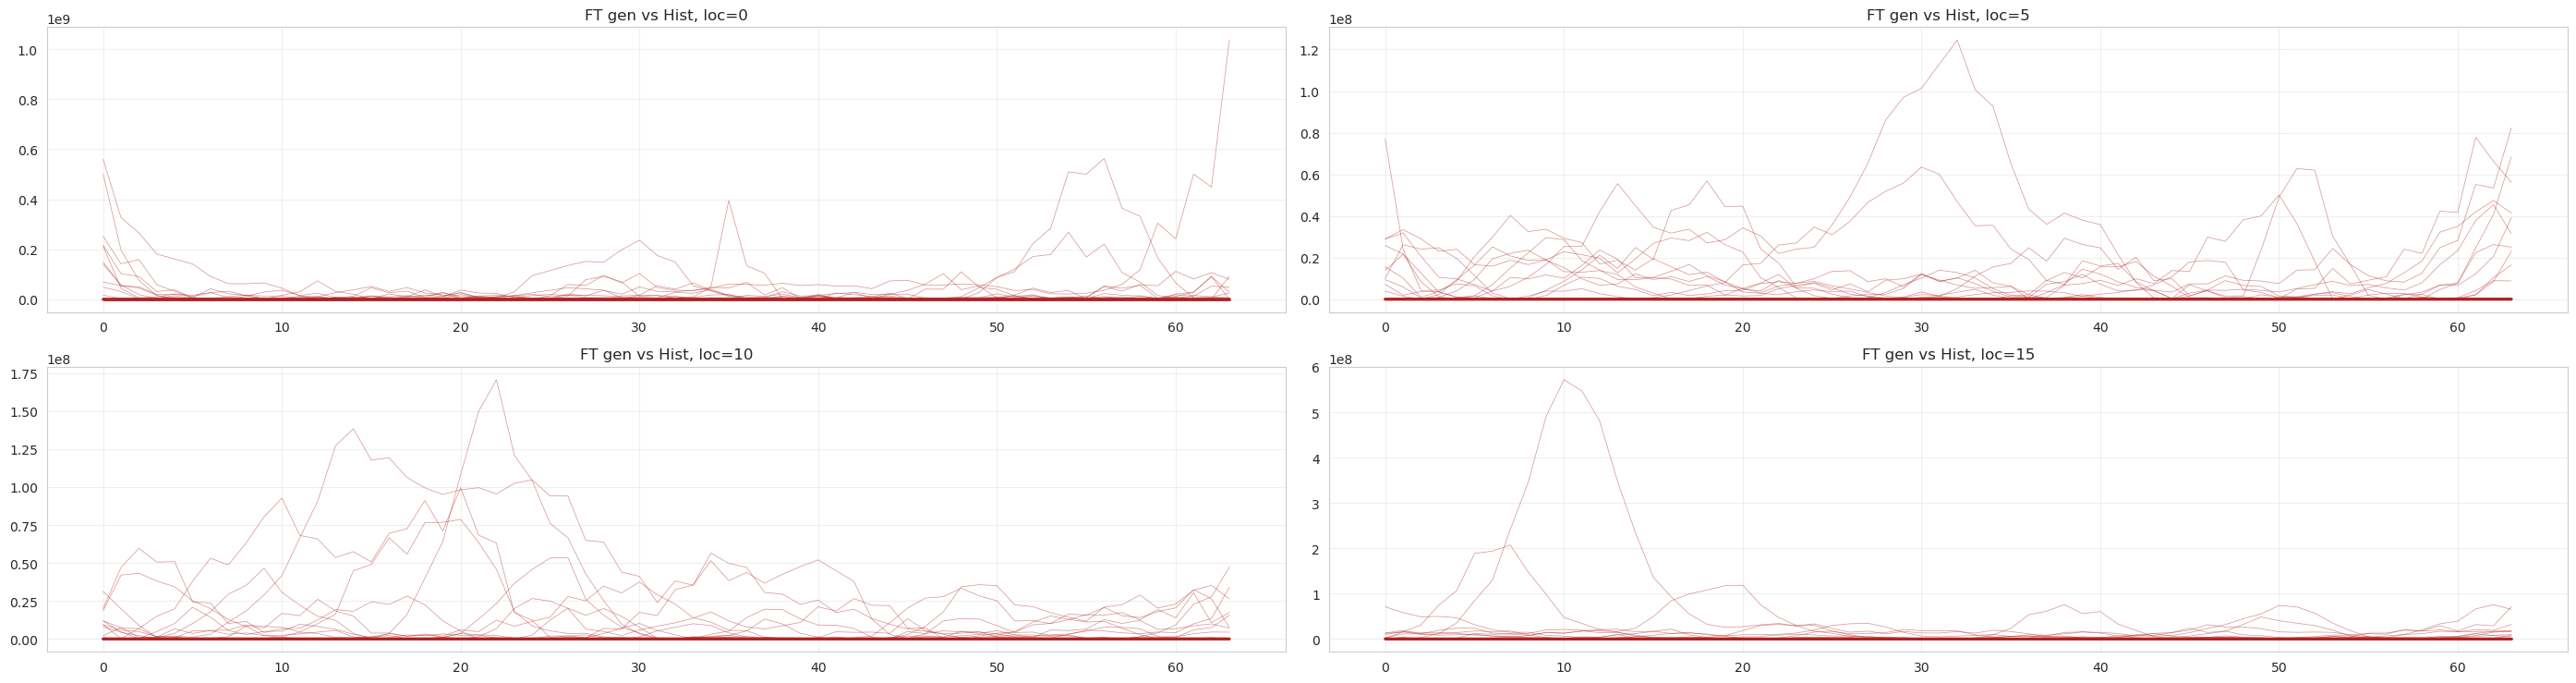

In [52]:
n_show = min(batch_size, 10)

fig, axes = plt.subplots(2, 2, figsize=(2.8 * n_show, 7.5), dpi=100)
for k, loc in enumerate([ 0, 5, 10, 15]):
    ax = axes.flat[k]
    for i in np.arange(3):
        hist_img = dataset.get_sample_raw(i)
        idplots.show_tensor_image(hist_img, ax=ax, place=loc, multi=False) # thicker curve are historical data
    for i in np.arange(n_show):
        gen_img = dataset.apply_transform_inv(ft_samples[250][i]) # -1 because i want the last step of the diffusion
        idplots.show_tensor_image(gen_img, ax=ax, place=loc, multi=True) # thinner curve are generation
        
    ax.set_title(f"FT gen vs Hist, loc={loc}")
    ax.grid(visible=True, alpha=0.3)
plt.tight_layout()
plt.show()